# Übung 6 – Mobilithek: Kfz-Neuzulassungen 2025 (KBA-Statistik FZ 4)

Diesmal keine eigene Messung, sondern **amtliche Open Data**: Die **Mobilithek** ist der nationale
Zugangspunkt für Mobilitätsdaten (BMDV, Nachfolgerin von mCLOUD und MDM). Das
**Kraftfahrt-Bundesamt (KBA)** veröffentlicht dort u. a. seine Zulassungsstatistiken. Wir analysieren
`fz4_2025.xlsx`: **„Neuzulassungen von Kraftfahrzeugen und Kraftfahrzeuganhängern nach Herstellern
und Handelsnamen (FZ 4), Jahr 2025“** – die komplette Jahresbilanz aller Neuzulassungen in
Deutschland in 12 Tabellenblättern (Pkw, Krafträder, Busse, Lkw, Zugmaschinen, Anhänger, …).

**Leitfragen**

1. **Marktstruktur:** Wie konzentriert ist der Pkw-Neuwagenmarkt 2025, und welche Rolle spielen
   neue – vor allem chinesische – Hersteller?
2. **Antriebsarten:** Welche Antriebe dominieren die Neuzulassungen? Unterscheiden sich
   Motorleistung und Haltergruppen (privat, Alter) je Antrieb?
3. **Regionale Muster:** Wie unterscheiden sich die Bundesländer – im Volumen je Einwohner:in,
   in der Herstellerwahl („Heimvorteil“) und im Fahrzeugklassen-Mix?

**Methodischer Rahmen:** Anders als in Übung 5 (kurze eigene Feldmessung mit unsicheren Uhren)
liegt hier eine **Vollerhebung** vor: Jede Zulassung des Jahres 2025 ist erfasst. Es gibt keinen
Stichprobenfehler, den ein Hypothesentest quantifizieren könnte – wir arbeiten deshalb bewusst
**deskriptiv mit Effektstärken** (Anteile, Verhältnisse). Die Begründung im Detail folgt in
Abschnitt 7.

**Aufbau:** Setup → Datenstruktur & Einlesen → Datenqualität → Marktstruktur → Antriebsarten →
Bundesländer → Deskriptiv vs. Inferenz → Fazit.

## 1. Setup und Dateninventar

Farbsystem wie in Übung 4/5 (feste, CVD-geprüfte Palette; Farben werden Entitäten fest zugeordnet,
nie durchrotiert). Danach ein Blick auf den Aufbau der Arbeitsmappe.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)

# ── Farbsystem (wie in Übung 4/5, CVD-geprüft) ───────────────────────────────
SERIES = ["#2a78d6", "#1baf7a", "#eda100", "#008300",
          "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
SURFACE = "#fcfcfb"
INK, INK2 = "#0b0b0b", "#52514e"
GRAU = "#9a9891"

# Feste Farb-Zuordnung nach Entität (nie umsortieren):
COL_FUEL = {"Hybrid": SERIES[0], "Elektro": SERIES[1], "Benzin": SERIES[2],
            "Diesel": SERIES[4], "Gas": SERIES[3], "Wasserstoff": SERIES[6],
            "nicht getypt": GRAU}
COL_KLASSE = {"Krafträder": SERIES[0], "Lkw": SERIES[2], "Zugmaschinen": SERIES[3],
              "Busse": SERIES[4], "Sonst. Kfz": GRAU}
COL_BAR = SERIES[0]   # neutrale Balken (Ranglisten)

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c8c3", "axes.labelcolor": INK2,
    "axes.titlesize": 12, "axes.titlelocation": "left", "axes.titlepad": 10,
    "grid.color": "#d8d7d2", "grid.linewidth": 0.6, "grid.alpha": 0.7,
    "text.color": INK, "xtick.color": INK2, "ytick.color": INK2,
    "lines.linewidth": 2.0, "legend.frameon": False,
    "axes.prop_cycle": plt.cycler(color=SERIES),
})

def tsd(n):
    # 1234567 -> '1.234.567' (deutsche Tausenderpunkte)
    return f"{n:,.0f}".replace(",", ".")

BASE_DIR = Path.cwd()
XLSX = BASE_DIR / "fz4_2025.xlsx"
print(f"Arbeitsverzeichnis: {BASE_DIR}")
print(f"Datei: {XLSX.name} ({XLSX.stat().st_size/1024:.0f} kB)\n")

xl = pd.ExcelFile(XLSX)
RAW = {name: xl.parse(name, header=None) for name in xl.sheet_names}
for name, df in RAW.items():
    titel = str(df.iloc[5, 1]) if name.startswith("FZ") else ""
    print(f"{name:18s} {df.shape[0]:5d} Zeilen x {df.shape[1]:2d} Spalten   {titel[:84]}")

Arbeitsverzeichnis: c:\Users\kevin\OneDrive - stud.tu-darmstadt.de\Uni_Master\Master_BauIng_4. Semester\Small and Big Data in der Verkehrstechnik\Übung 6 - Mobilithek
Datei: fz4_2025.xlsx (730 kB)



Deckblatt             16 Zeilen x  1 Spalten   
Impressum             26 Zeilen x  3 Spalten   
Inhaltsverzeichnis    39 Zeilen x  3 Spalten   
FZ 4.1                92 Zeilen x 10 Spalten   FZ 4.1 Personenkraftwagen im Jahr 2025 nach Herstellern und ausgewählten Merkmalen
FZ 4.2              2545 Zeilen x 14 Spalten   FZ 4.2 Personenkraftwagen im Jahr 2025 nach Herstellern, Handelsnamen und ausgewählt
FZ 4.3               118 Zeilen x 22 Spalten   FZ 4.3 Personenkraftwagen im Jahr 2025 nach Herstellern und Bundesländern
FZ 4.4              2544 Zeilen x 22 Spalten   FZ 4.4 Personenkraftwagen im Jahr 2025 nach Herstellern, Handelsnamen und Bundesländ
FZ 4.5               230 Zeilen x 22 Spalten   FZ 4.5 Krafträder im Jahr 2025 nach Herstellern und Bundesländern
FZ 4.6                24 Zeilen x 21 Spalten   FZ 4.6 Kraftomnibusse im Jahr 2025 nach Herstellern und Bundesländern
FZ 4.7                48 Zeilen x 21 Spalten   FZ 4.7 Lastkraftwagen im Jahr 2025 nach Herstellern und Bundeslä

## 2. Datenstruktur und Einlesen

Die Datei ist eine **Präsentations-Excel für Menschen**, kein maschinenlesbares Austauschformat.
Vier Eigenheiten muss der Parser beherrschen:

1. **Kopfbereich:** Jedes Blatt beginnt mit Titelzeilen; die eigentliche Tabelle startet erst ab
   Zeile 9/10, mit zweizeiligen Spaltenköpfen.
2. **Verbundene Zellen:** Herstellernamen (FZ 4.2), Handelsnamen mit mehreren Typschlüsseln und
   Blockbezeichnungen (FZ 4.3) stehen nur in der **ersten** Zeile ihres Blocks – beim Import
   entstehen `NaN`-Folgezeilen, die per `ffill` aufgefüllt werden müssen. Wer das übersieht,
   verliert still mehr als die Hälfte der Daten: In unserem ersten Parsing-Versuch blieben nur
   1,2 von 2,86 Mio. Zulassungen übrig.
3. **Summen- und Fußzeilen:** `ZUSAMMEN`-Zeilen je Hersteller und die `INSGESAMT`-Zeile am
   Blattende sind keine Datenzeilen – aber ideale **Kontrollsummen** (Abschnitt 3). Darunter folgen
   Hinweis- und Copyright-Zeilen. Wir schneiden deshalb **markerbasiert** an der `INSGESAMT`-Zeile
   ab statt mit festen Zeilennummern.
4. **KBA-Symbolik** (Zeichenerklärung im Blatt „Inhaltsverzeichnis“): `-` = „nichts vorhanden“
   (→ 0), `.` / `/` / `X` = unbekannt, unsicher oder nicht sinnvoll (→ `NaN`).

In [2]:
LAENDER = ["BW","BY","BE","BB","HB","HH","HE","MV","NI","NW","RP","SL","SN","ST","SH","TH"]
LAND_NAME = {"BW":"Baden-Württemberg","BY":"Bayern","BE":"Berlin","BB":"Brandenburg",
             "HB":"Bremen","HH":"Hamburg","HE":"Hessen","MV":"Mecklenburg-Vorpommern",
             "NI":"Niedersachsen","NW":"Nordrhein-Westfalen","RP":"Rheinland-Pfalz",
             "SL":"Saarland","SN":"Sachsen","ST":"Sachsen-Anhalt",
             "SH":"Schleswig-Holstein","TH":"Thüringen"}

def zahlen(s):
    # KBA-Symbolik: '-' = nichts vorhanden (-> 0); '.', '/', 'X' = unbekannt (-> NaN)
    s = s.astype(object).mask(s.astype(str).str.strip().eq("-"), 0)
    return pd.to_numeric(s, errors="coerce")

# ── FZ 4.1: Pkw je Hersteller mit Haltermerkmalen ────────────────────────────
t = RAW["FZ 4.1"].iloc[9:, 1:10].copy()
t.columns = ["Hersteller","SchlNr","Insgesamt","Wohnmobile","privat","bis29","ab60",
             "Halterinnen","Vermietung"]
stop = t.index[t["Hersteller"].eq("INSGESAMT")][0]
TOTAL_PKW = int(zahlen(t.loc[[stop], "Insgesamt"]).iloc[0])
hersteller = t.loc[:stop-1].dropna(subset=["Hersteller"]).copy()
for c in hersteller.columns[2:]:
    hersteller[c] = zahlen(hersteller[c])

# ── FZ 4.2: Pkw auf Modellebene (Handelsname, kW, Kraftstoffart) ─────────────
t = RAW["FZ 4.2"].iloc[9:, 1:14].copy()
t.columns = ["Hersteller","Handelsname","TypSchl","kW","Kraftstoff","Allrad","Aufbau",
             "Insgesamt","Wohnmobile","privat","bis29","ab60","Halterinnen"]
stop = t.index[t["Hersteller"].eq("INSGESAMT")][0]
t = t.loc[:stop-1]
t["Hersteller"] = t["Hersteller"].ffill()      # Name steht nur in der 1. Zeile des Blocks
for c in ["kW","Insgesamt","Wohnmobile","privat","bis29","ab60","Halterinnen"]:
    t[c] = zahlen(t[c])
summen  = t[t["Handelsname"].eq("ZUSAMMEN")].set_index("Hersteller")   # Kontrollsummen
modelle = t[t["Insgesamt"].notna() & t["Handelsname"].ne("ZUSAMMEN")].copy()
modelle["Handelsname"] = modelle.groupby("Hersteller")["Handelsname"].ffill()  # verbundene Zellen

FUEL_NAME = {"B":"Benzin","D":"Diesel","E":"Elektro","H":"Hybrid","G":"Gas","S":"Wasserstoff"}
modelle["Antrieb"] = modelle["Kraftstoff"].map(FUEL_NAME).fillna("nicht getypt")

# ── FZ 4.3: Pkw je Hersteller x Bundesland ───────────────────────────────────
t = RAW["FZ 4.3"].iloc[8:, 1:22].copy()
t.columns = ["Block","Hersteller","SchlNr"] + LAENDER + ["Sonstige","DE"]
t["Block"] = t["Block"].ffill()
blk = t[t["Block"].eq("PERSONENKRAFTWAGEN INSGESAMT")]
laender = blk[blk["Hersteller"].notna()].copy()
for c in LAENDER + ["Sonstige","DE"]:
    laender[c] = zahlen(laender[c]).fillna(0)
laender = laender.set_index("Hersteller")

# ── Fahrzeugklassen: Summenzeilen der übrigen Blätter ────────────────────────
def klassen_zeile(blatt, label):
    # letzte Zeile mit dem Label = Summenzeile; 18 Werte = 16 Länder + Sonstige + Deutschland
    r = RAW[blatt]
    hits = [i for i in r.index if label in [str(v).strip() for v in r.iloc[i, :4].tolist()]]
    zeile = r.iloc[hits[-1]].map(lambda v: 0 if str(v).strip() == "-" else v)
    return pd.to_numeric(zeile, errors="coerce").dropna().iloc[-18:].to_numpy()

klassen = pd.DataFrame({
    "Pkw":          laender[LAENDER + ["Sonstige","DE"]].sum().to_numpy(),
    "Krafträder":   klassen_zeile("FZ 4.5",  "KRAFTRÄDER INSGESAMT"),
    "Busse":        klassen_zeile("FZ 4.6",  "INSGESAMT"),
    "Lkw":          klassen_zeile("FZ 4.7",  "INSGESAMT"),
    "Zugmaschinen": klassen_zeile("FZ 4.9",  "ZUGMASCHINEN INSGESAMT"),
    "Sonst. Kfz":   klassen_zeile("FZ 4.10", "INSGESAMT"),
}, index=LAENDER + ["Sonstige","DE"])

print(f"FZ 4.1:  {len(hersteller)} Hersteller, Summe {tsd(hersteller['Insgesamt'].sum())} Pkw")
print(f"FZ 4.2:  {len(modelle)} Modellzeilen, Summe {tsd(modelle['Insgesamt'].sum())} Pkw")
print(f"FZ 4.3:  {len(laender)} Hersteller x 16 Länder, Deutschland-Spalte {tsd(laender['DE'].sum())}")
print(f"Alle Fahrzeugklassen (Deutschland): {tsd(klassen.loc['DE'].sum())} Kfz")

FZ 4.1:  78 Hersteller, Summe 2.857.591 Pkw
FZ 4.2:  2453 Modellzeilen, Summe 2.853.022 Pkw
FZ 4.3:  78 Hersteller x 16 Länder, Deutschland-Spalte 2.857.591
Alle Fahrzeugklassen (Deutschland): 3.410.587 Kfz


## 3. Datenqualität

Der Vorteil des Tabellenaufbaus: Das KBA liefert die **Kontrollsummen gleich mit**. Wir prüfen die
interne Konsistenz auf drei Ebenen – innerhalb der Blätter (Zeilen-/Spaltensummen), zwischen den
Blättern (FZ 4.1 ↔ 4.2 ↔ 4.3) und über die Fahrzeugklassen hinweg (Summe der Klassen ↔ FZ 4.11).

In [3]:
kontrollen = []
def kontrolle(name, ist, soll):
    kontrollen.append({"Kontrolle": name, "ist": tsd(ist), "soll": tsd(soll),
                       "ok": "✓" if ist == soll else "✗"})

kontrolle("FZ 4.1: Summe aller Hersteller = INSGESAMT",
          int(hersteller["Insgesamt"].sum()), TOTAL_PKW)

sonst_hersteller = int(summen.loc["SONSTIGE HERSTELLER", "Insgesamt"])
kontrolle("FZ 4.2: Modellzeilen + sonstige Hersteller = INSGESAMT",
          int(modelle["Insgesamt"].sum()) + sonst_hersteller, TOTAL_PKW)

je_h = modelle.groupby("Hersteller")["Insgesamt"].sum()
f1   = hersteller.set_index("Hersteller")["Insgesamt"].drop("SONSTIGE HERSTELLER")
kontrolle("FZ 4.2 ↔ FZ 4.1 je Hersteller (max. Abweichung)",
          int((je_h - f1).abs().max()), 0)

kontrolle("FZ 4.3: Deutschland-Spalte = INSGESAMT",
          int(laender["DE"].sum()), TOTAL_PKW)
kontrolle("FZ 4.3: 16 Länder + Sonstige = Deutschland (max. Abweichung je Zeile)",
          int((laender[LAENDER + ['Sonstige']].sum(axis=1) - laender["DE"]).abs().max()), 0)

fz411 = klassen_zeile("FZ 4.11", "INSGESAMT")
kontrolle("Summe der 6 Fahrzeugklassen = FZ 4.11 (max. Abweichung je Land)",
          int(np.abs(klassen.sum(axis=1).to_numpy() - fz411).max()), 0)

print(pd.DataFrame(kontrollen).to_string(index=False))

nicht_getypt = modelle.loc[modelle["Antrieb"].eq("nicht getypt"), "Insgesamt"].sum()
print(f"\nOhne Typdaten ('SONSTIGE/NICHT GETYPT'): {tsd(nicht_getypt)} Pkw "
      f"= {nicht_getypt/TOTAL_PKW*100:.1f} % (keine Kraftstoffart, keine kW)")
fehlt = modelle[modelle["Kraftstoff"].isna() & modelle["Handelsname"].ne("SONSTIGE/NICHT GETYPT")]
print(f"Getypte Modellzeilen ohne Kraftstoffangabe: {len(fehlt)}")

print("\nStolperfalle kW – Beispiel VW ID.3:")
bsp = modelle[modelle["Handelsname"].astype(str).str.startswith("ID.3 PRO 150")]
print(bsp[["Hersteller","Handelsname","TypSchl","kW","Kraftstoff","Insgesamt"]].to_string(index=False))

                                                            Kontrolle       ist      soll ok
                           FZ 4.1: Summe aller Hersteller = INSGESAMT 2.857.591 2.857.591  ✓
               FZ 4.2: Modellzeilen + sonstige Hersteller = INSGESAMT 2.857.591 2.857.591  ✓
                      FZ 4.2 ↔ FZ 4.1 je Hersteller (max. Abweichung)         0         0  ✓
                               FZ 4.3: Deutschland-Spalte = INSGESAMT 2.857.591 2.857.591  ✓
FZ 4.3: 16 Länder + Sonstige = Deutschland (max. Abweichung je Zeile)         0         0  ✓
      Summe der 6 Fahrzeugklassen = FZ 4.11 (max. Abweichung je Land)         0         0  ✓

Ohne Typdaten ('SONSTIGE/NICHT GETYPT'): 53.399 Pkw = 1.9 % (keine Kraftstoffart, keine kW)
Getypte Modellzeilen ohne Kraftstoffangabe: 0

Stolperfalle kW – Beispiel VW ID.3:
    Hersteller     Handelsname TypSchl   kW Kraftstoff  Insgesamt
VOLKSWAGEN (D) ID.3 PRO 150 KW     CKV 70.0          E      16324


### Befund

Alle Kontrollsummen gehen **exakt** auf – innerhalb der Blätter, zwischen den Blättern und über
alle sechs Fahrzeugklassen. Für eine frei heruntergeladene Open-Data-Datei ist das bemerkenswert:
keine Rundungsdifferenzen, keine Geheimhaltungslücken in den Summen. Drei Dinge sind trotzdem
festzuhalten:

- **kW ist nicht gleich kW:** Die Leistungsangabe stammt aus der Zulassungsbescheinigung. Bei
  Elektroautos steht dort die **30-Minuten-Dauerleistung**, nicht die Spitzenleistung – der
  „ID.3 PRO **150 kW**“ erscheint in der Tabelle mit **70 kW**. Leistungsvergleiche zwischen
  Verbrennern und E-Autos wären damit systematisch verzerrt (→ Abschnitt 5).
- **1,9 % ohne Typdaten:** 53.399 Pkw laufen als „SONSTIGE/NICHT GETYPT“ ohne Kraftstoffart und
  kW. Bei Antriebsanteilen führen wir sie als eigene Kategorie mit.
- **Hersteller ≠ Marke ≠ Konzern:** Die Statistik nutzt den KBA-**Herstellerschlüssel**:
  Mercedes-Benz firmiert als DAIMLER, Opel/Peugeot/Citroën/Fiat weitgehend als STELLANTIS,
  Renaults E-Sparte separat als AMPERE. Laut Hinweiszeile heißt SSANGYONG seit April 2025 KGM.

## 4. Marktstruktur: Wer verkauft die 2,86 Mio. Pkw? (Leitfrage 1)

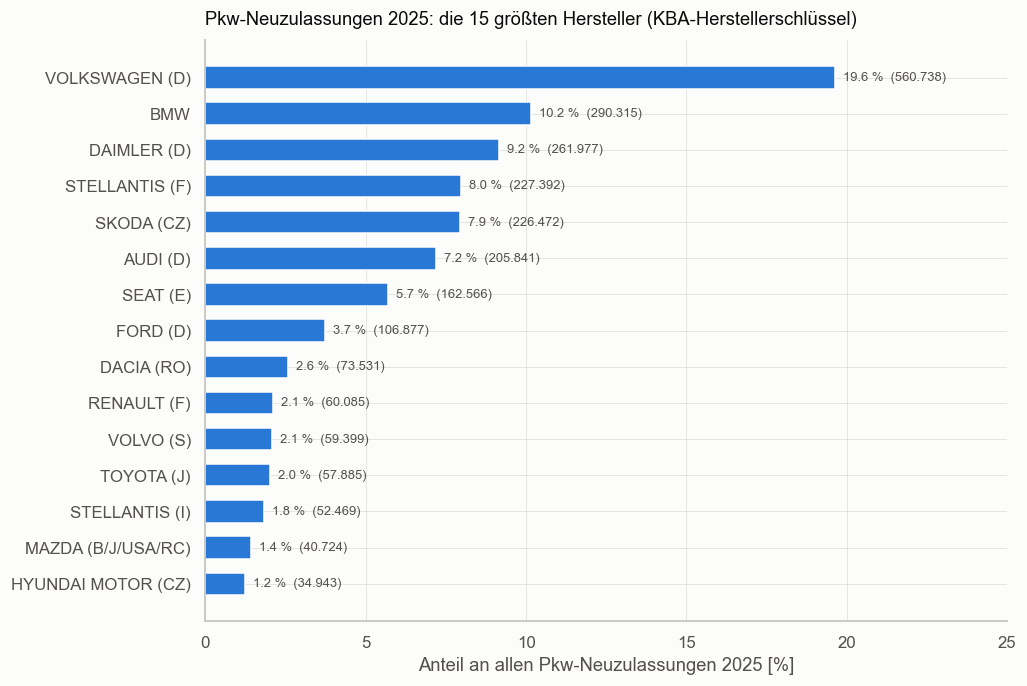

Konzentration: CR5 = 54.8 %   CR10 = 76.1 %   HHI = 835
VW-Konzern (VW+Audi+Škoda+Seat+Porsche): 41.5 %
Chinesische Hersteller (Kürzel 'RC'): 13 Hersteller, zusammen 2.4 % — SAIC 0.9 %, BYD AUTO 0.8 %, LEAPMOTOR 0.3 %
TESLA (USA): 19.390 Pkw = 0.68 %


In [4]:
rang = hersteller.sort_values("Insgesamt", ascending=False).reset_index(drop=True)
rang["Anteil"] = rang["Insgesamt"] / TOTAL_PKW * 100

top15 = rang.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(9.5, 6.4))
ax.barh(top15["Hersteller"], top15["Anteil"], color=COL_BAR, height=0.62)
for y, (ant, ins) in enumerate(zip(top15["Anteil"], top15["Insgesamt"])):
    ax.text(ant + 0.25, y, f"{ant:.1f} %  ({tsd(ins)})", va="center", fontsize=8.5, color=INK2)
ax.set_xlim(0, 25)
ax.set_xlabel("Anteil an allen Pkw-Neuzulassungen 2025 [%]")
ax.set_title("Pkw-Neuzulassungen 2025: die 15 größten Hersteller (KBA-Herstellerschlüssel)")
plt.tight_layout()
plt.show()

anteile = rang.set_index("Hersteller")["Anteil"] / 100
print(f"Konzentration: CR5 = {anteile.head(5).sum()*100:.1f} %   "
      f"CR10 = {anteile.head(10).sum()*100:.1f} %   HHI = {(anteile**2).sum()*10000:.0f}")

vw_gruppe = ["VOLKSWAGEN (D)", "AUDI (D)", "SKODA (CZ)", "SEAT (E)", "PORSCHE"]
print(f"VW-Konzern (VW+Audi+Škoda+Seat+Porsche): {anteile[vw_gruppe].sum()*100:.1f} %")

rc = rang[rang["Hersteller"].str.contains("(RC)", regex=False)]
print(f"Chinesische Hersteller (Kürzel 'RC'): {len(rc)} Hersteller, zusammen {rc['Anteil'].sum():.1f} % — "
      + ", ".join(f"{h.replace(' (RC)','')} {a:.1f} %" for h, a in
                  zip(rc["Hersteller"].head(3), rc["Anteil"].head(3))))
tesla = rang[rang["Hersteller"].eq("TESLA (USA)")].iloc[0]
print(f"TESLA (USA): {tsd(tesla['Insgesamt'])} Pkw = {tesla['Anteil']:.2f} %")

### Was die Zahlen sagen

**Volkswagen dominiert mit 19,6 %** – fast jeder fünfte neue Pkw. Auf Herstellerebene wirkt der
Markt mit einem **HHI von 835** formal „unkonzentriert“ (kartellrechtliche Schwelle: 1.000–1.500 =
moderat). Das täuscht aber: Zählt man die Konzernmarken zusammen, kommt allein der **VW-Konzern
auf 41,5 %**, und die fünf größten Hersteller (CR5) vereinen **54,8 %**, die Top 10 (CR10)
**76,1 %**. Die Wahl der Aggregationsebene – Herstellerschlüssel vs. Konzern – entscheidet hier
über das Bild; ein schönes Beispiel dafür, dass man Kennzahlen nie ohne ihre Definition
interpretieren sollte.

Die **13 chinesischen Hersteller** bringen es zusammen erst auf **2,4 %** – angeführt von SAIC
(Marke MG, 0,9 %) und BYD (0,8 %). Viele Anbieter, wenig Volumen: Der oft beschworene
„China-Schock“ ist in den Zulassungszahlen 2025 (noch) klein. **Tesla liegt mit 0,68 %**
(19.390 Pkw) inzwischen weit hinter den etablierten Volumenherstellern.

## 5. Antriebsarten: Wie weit ist die Antriebswende? (Leitfrage 2)

FZ 4.2 führt jede Modellvariante mit **Kraftstoffart** und **kW**. Die Codes erschließen sich aus
den Daten (eine Legende enthält die Datei nicht): **B** Benzin, **D** Diesel, **E** Elektro (BEV),
**H** Hybrid – offenbar *alle* Hybridformen vom Mild- bis zum Plug-in-Hybrid (der BMW 120, ein
Mildhybrid-Benziner, läuft unter H), **G** Gas/LPG, **S** Wasserstoff (einziges Modell: Toyota
Mirai). Zu beachten: Die kW-Angabe ist bei E-Autos die **Dauerleistung** (Abschnitt 3).

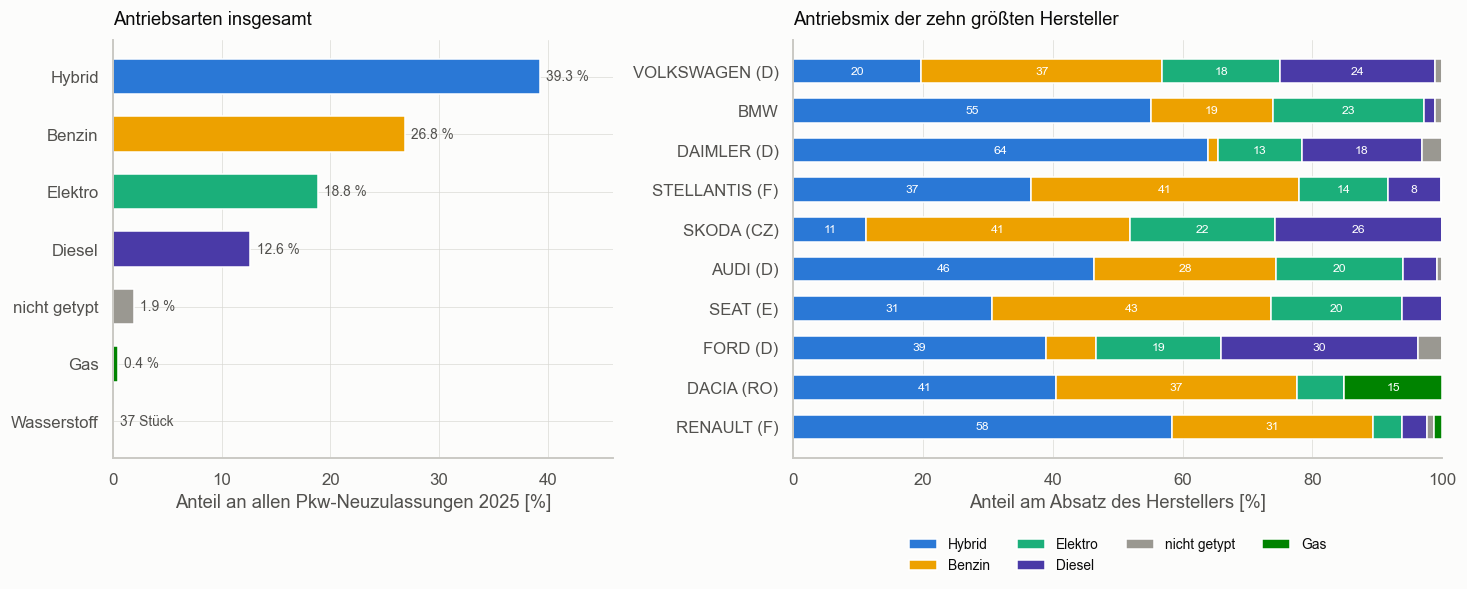

Nische im Detail – Gas- und Wasserstoffmodelle:
 Hersteller    Handelsname    kW Kraftstoff  Insgesamt
 DACIA (RO)        BIGSTER 103.0          G        579
 DACIA (RO) DUSTER,SANDERO  67.0          G       6761
 DACIA (RO) DUSTER,SANDERO  84.0          G         15
 DACIA (RO)         JOGGER  67.0          G       3733
RENAULT (F)         CAPTUR  67.0          G        392
RENAULT (F)           CLIO  67.0          G        422
 TOYOTA (J)   TOYOTA MIRAI  48.0          S         37


In [5]:
antrieb = modelle.groupby("Antrieb")["Insgesamt"].sum()
reihenfolge = ["Hybrid", "Benzin", "Elektro", "Diesel", "nicht getypt", "Gas", "Wasserstoff"]
antrieb = antrieb.reindex(reihenfolge).fillna(0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.6), gridspec_kw={"width_ratios": [1, 1.3]})

# links: Verteilung über alle Pkw 2025
ant_pct = antrieb / TOTAL_PKW * 100
ax1.barh(antrieb.index[::-1], ant_pct[::-1],
         color=[COL_FUEL[a] for a in antrieb.index[::-1]], height=0.62)
for y, a in enumerate(antrieb.index[::-1]):
    lbl = f"{ant_pct[a]:.1f} %" if antrieb[a] > 5000 else f"{tsd(antrieb[a])} Stück"
    ax1.text(ant_pct[a] + 0.6, y, lbl, va="center", fontsize=9, color=INK2)
ax1.set_xlim(0, 46)
ax1.set_xlabel("Anteil an allen Pkw-Neuzulassungen 2025 [%]")
ax1.set_title("Antriebsarten insgesamt")

# rechts: Antriebsmix der zehn größten Hersteller (100 % gestapelt)
top10 = rang["Hersteller"].head(10).tolist()
mix = (modelle[modelle["Hersteller"].isin(top10)]
       .pivot_table(index="Hersteller", columns="Antrieb", values="Insgesamt", aggfunc="sum")
       .reindex(index=top10).fillna(0))
mix = mix.div(mix.sum(axis=1), axis=0) * 100
mixr = mix.iloc[::-1]
links = np.zeros(len(mixr))
for a in reihenfolge:
    if a not in mixr.columns:
        continue
    ax2.barh(mixr.index, mixr[a], left=links, color=COL_FUEL[a], height=0.62, label=a)
    mitte = links + mixr[a] / 2
    for y, (v, m) in enumerate(zip(mixr[a], mitte)):        # Segmente >= 8 % beschriften
        if v >= 8:
            ax2.text(m, y, f"{v:.0f}", va="center", ha="center", fontsize=8, color="white")
    links += mixr[a].to_numpy()
ax2.set_xlim(0, 100)
ax2.set_xlabel("Anteil am Absatz des Herstellers [%]")
ax2.set_title("Antriebsmix der zehn größten Hersteller")
ax2.legend(ncols=4, loc="upper center", bbox_to_anchor=(0.5, -0.16), fontsize=9)
plt.tight_layout()
plt.show()

print("Nische im Detail – Gas- und Wasserstoffmodelle:")
gs = modelle[modelle["Kraftstoff"].isin(["G", "S"])]
print(gs[["Hersteller","Handelsname","kW","Kraftstoff","Insgesamt"]].to_string(index=False))

### Was die Zahlen sagen

**Hybride sind 2025 die größte Antriebsgruppe (39,3 %)** – wobei der Sammelcode H vom Mildhybrid
bis zum Plug-in alles bündelt und den Wert entsprechend aufbläht. Reine **Benziner (26,8 %)**
liegen noch vor den **Elektroautos (18,8 %, 538.177 Stück)**; der **Diesel ist auf 12,6 %**
abgerutscht. **Gas ist mit 0,4 % praktisch tot** – und fast ausschließlich ein Dacia-Phänomen
(LPG-Versionen von Duster, Sandero, Jogger). Wasserstoff: **37 Toyota Mirai** bundesweit.

Der Blick auf die Hersteller zeigt sehr unterschiedliche Strategien: **Daimler (64 % H) und BMW
(55 % H)** setzen massiv auf (Mild-)Hybride, **BMW schafft zugleich 23 % E-Anteil**. **Škoda ist
mit 26 % Diesel** und **Ford mit 30 %** die letzten Diesel-Bastionen im Top-10-Feld, während
**Dacia** als Einziger nennenswert Gas verkauft (15 %). Der niedrige E-Anteil von **Renault
(4,5 %)** ist ein Artefakt des Herstellerschlüssels: Renaults Elektroautos laufen separat unter
AMPERE (10.542 Pkw, 100 % E).

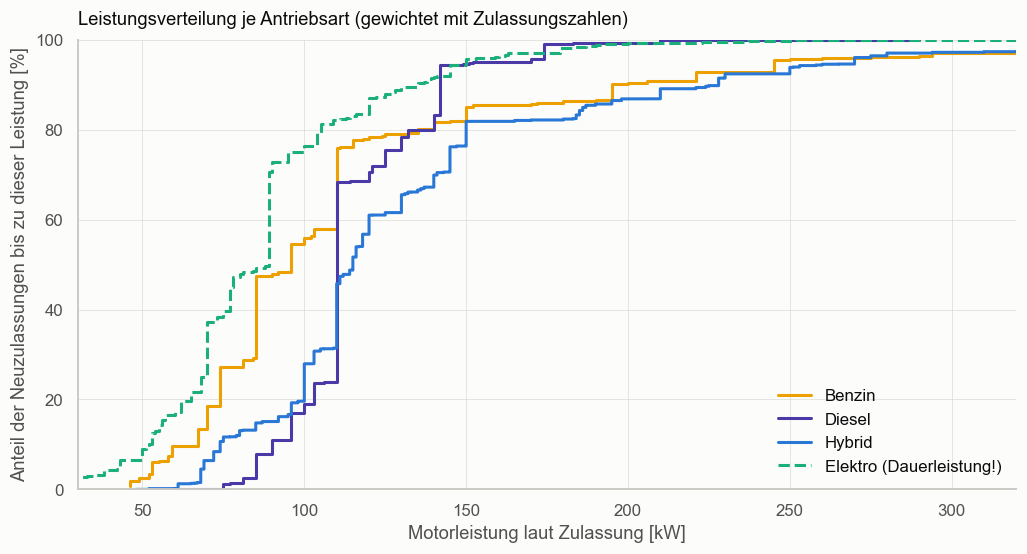

Antrieb  Q25 [kW]  Median [kW]  Q75 [kW] Zulassungen
 Benzin        74           96       110     767.181
 Diesel       110          110       125     360.415
 Hybrid       100          115       145   1.121.911
Elektro        68           89       100     538.177


In [6]:
# Motorleistung je Antrieb – zulassungsgewichtete Verteilungsfunktion (ECDF)
def gew_quantil(kw, gewicht, q):
    idx = np.argsort(kw)
    kw, gewicht = kw[idx], gewicht[idx]
    cum = np.cumsum(gewicht) / gewicht.sum()
    return kw[np.searchsorted(cum, q)]

fig, ax = plt.subplots(figsize=(9.5, 5.2))
qzeilen = []
for a in ["Benzin", "Diesel", "Hybrid", "Elektro"]:
    m = modelle[modelle["Antrieb"].eq(a) & modelle["kW"].notna() & (modelle["Insgesamt"] > 0)]
    m = m.sort_values("kW")
    kw, w = m["kW"].to_numpy(), m["Insgesamt"].to_numpy()
    stil = "--" if a == "Elektro" else "-"    # gestrichelt: Dauerleistung, nicht vergleichbar
    ax.plot(kw, np.cumsum(w) / w.sum() * 100, stil, color=COL_FUEL[a],
            drawstyle="steps-post", label=a + (" (Dauerleistung!)" if a == "Elektro" else ""))
    qzeilen.append({"Antrieb": a,
                    "Q25 [kW]": int(gew_quantil(kw, w, 0.25)),
                    "Median [kW]": int(gew_quantil(kw, w, 0.50)),
                    "Q75 [kW]": int(gew_quantil(kw, w, 0.75)),
                    "Zulassungen": tsd(w.sum())})
ax.set_xlim(30, 320)
ax.set_ylim(0, 100)
ax.set_xlabel("Motorleistung laut Zulassung [kW]")
ax.set_ylabel("Anteil der Neuzulassungen bis zu dieser Leistung [%]")
ax.set_title("Leistungsverteilung je Antriebsart (gewichtet mit Zulassungszahlen)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(pd.DataFrame(qzeilen).to_string(index=False))

### Was die Zahlen sagen

Neue **Diesel sind durchweg stark motorisiert** (Median 110 kW, extrem enge Verteilung: Q25 =
Median = 110 kW – das Segment ist auf wenige Volumenmodelle zusammengeschrumpft). **Hybride**
liegen ähnlich hoch (Median 115 kW), **Benziner** deutlich darunter (96 kW) – hier leben die
Klein- und Kompaktwagen (Aygo X, T-Cross & Co.). Die **Elektro-Kurve ist gestrichelt**, weil ihre
kW-Werte Dauerleistungen sind: Der nominelle Median von 89 kW entspricht realen Spitzenleistungen
von oft 150 kW und mehr – ein direkter Kurvenvergleich wäre der klassische Fehler „gleiche
Spaltenüberschrift, andere Messgröße“.

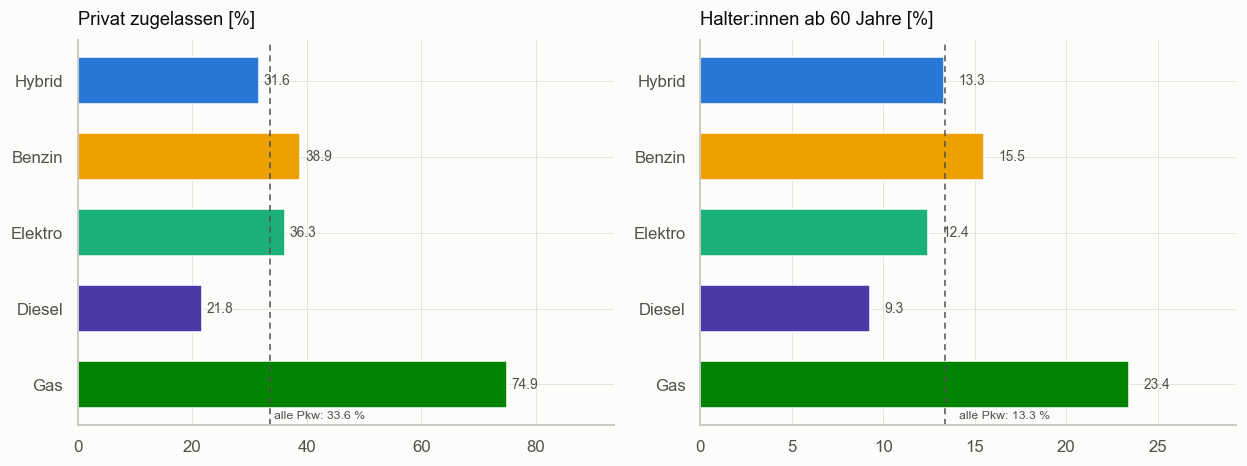

In [7]:
# Haltergruppen je Antrieb: Privatanteil und Anteil der Halter:innen ab 60
gr = modelle.groupby("Antrieb").agg(ins=("Insgesamt", "sum"), priv=("privat", "sum"),
                                    a60=("ab60", "sum"))
gr = gr.loc[["Hybrid", "Benzin", "Elektro", "Diesel", "Gas"]]      # ohne Kleinstgruppen
gr["privat_pct"] = gr["priv"] / gr["ins"] * 100
gr["a60_pct"] = gr["a60"] / gr["ins"] * 100
schnitt_priv = modelle["privat"].sum() / modelle["Insgesamt"].sum() * 100
schnitt_a60  = modelle["ab60"].sum() / modelle["Insgesamt"].sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
for ax, spalte, schnitt, titel in [
        (axes[0], "privat_pct", schnitt_priv, "Privat zugelassen [%]"),
        (axes[1], "a60_pct", schnitt_a60, "Halter:innen ab 60 Jahre [%]")]:
    d = gr[spalte][::-1]
    ax.barh(d.index, d, color=[COL_FUEL[a] for a in d.index], height=0.62)
    for y, v in enumerate(d):
        ax.text(v + 0.8, y, f"{v:.1f}", va="center", fontsize=9, color=INK2)
    ax.axvline(schnitt, color=INK2, lw=1, dashes=(4, 3))
    ax.text(schnitt + 0.8, -0.45, f"alle Pkw: {schnitt:.1f} %", fontsize=8, color=INK2)
    ax.set_xlim(0, max(d) * 1.25)
    ax.set_title(titel)
plt.tight_layout()
plt.show()

### Was die Zahlen sagen

Der **Diesel ist ein Flottenantrieb**: Nur noch 21,8 % der neuen Diesel gehen an Privatleute
(alle Pkw: 33,6 %). **Elektroautos liegen mit 36,3 % Privatanteil inzwischen leicht über dem
Durchschnitt** – die E-Nachfrage 2025 ist also keineswegs ein reines Dienstwagenphänomen mehr,
auch wenn Leasing über gewerbliche Halter hier unsichtbar bleibt. Auffälligster Ausreißer ist
**Gas mit 74,9 % Privatanteil und 23,4 % Senior:innen**: Die LPG-Dacias sind das Sparmodell für
preisbewusste Privatkäufer:innen. Bei den Halter:innen ab 60 führen sonst die Benziner (15,5 %),
während Diesel (9,3 %) und Elektro (12,4 %) darunter liegen.

## 6. Regionale Muster: die Bundesländer (Leitfrage 3)

FZ 4.3 schlüsselt jeden Hersteller nach dem **Zulassungsbezirk** auf – also dem Sitz der
Halterin/des Halters, nicht dem Nutzungsort. Zum Normieren nutzen wir die Bevölkerung der Länder
(Destatis, Fortschreibung 31.12.2023, gerundet).

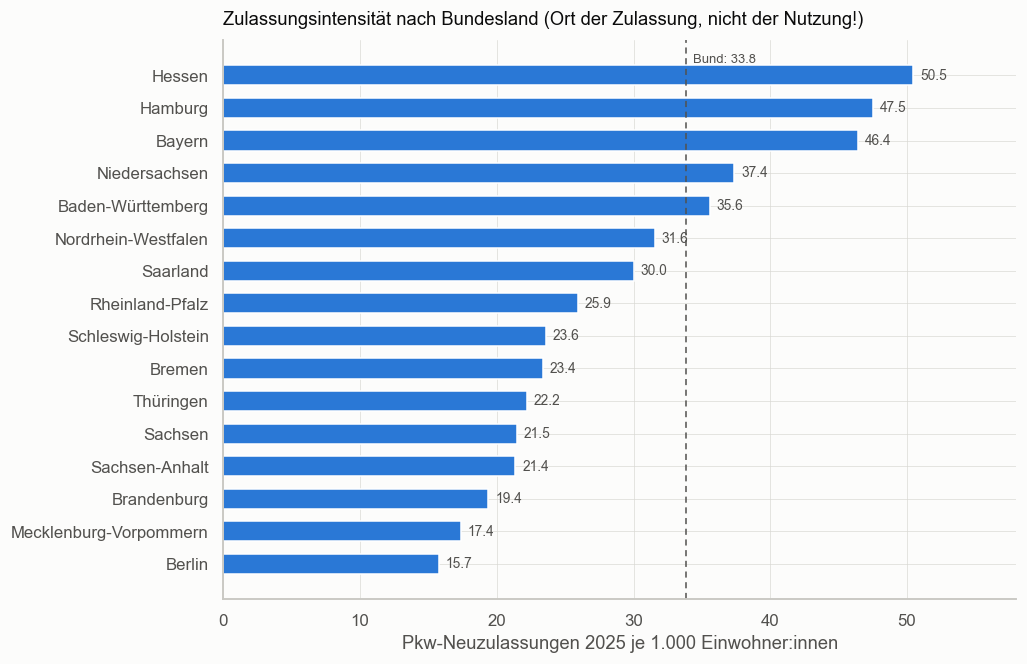

Spalte 'Sonstige' (Halter ohne Zuordnung/Ausland): 1.391 Pkw


In [8]:
EINWOHNER_MIO = {"BW": 11.28, "BY": 13.37, "BE": 3.78, "BB": 2.57, "HB": 0.69, "HH": 1.91,
                 "HE": 6.39, "MV": 1.63, "NI": 8.14, "NW": 18.19, "RP": 4.16, "SL": 0.99,
                 "SN": 4.09, "ST": 2.19, "SH": 2.95, "TH": 2.13}   # Destatis 31.12.2023

land_summe = laender[LAENDER].sum()
je_1000 = land_summe / (pd.Series(EINWOHNER_MIO) * 1e6) * 1000
schnitt = land_summe.sum() / (sum(EINWOHNER_MIO.values()) * 1e6) * 1000

ordnung = je_1000.sort_values()
fig, ax = plt.subplots(figsize=(9.5, 6.2))
ax.barh([LAND_NAME[k] for k in ordnung.index], ordnung, color=COL_BAR, height=0.62)
for y, v in enumerate(ordnung):
    ax.text(v + 0.5, y, f"{v:.1f}", va="center", fontsize=9, color=INK2)
ax.axvline(schnitt, color=INK2, lw=1, dashes=(4, 3))
ax.text(schnitt + 0.5, 15.4, f"Bund: {schnitt:.1f}", fontsize=8.5, color=INK2)
ax.set_xlim(0, 58)
ax.set_xlabel("Pkw-Neuzulassungen 2025 je 1.000 Einwohner:innen")
ax.set_title("Zulassungsintensität nach Bundesland (Ort der Zulassung, nicht der Nutzung!)")
plt.tight_layout()
plt.show()

print(f"Spalte 'Sonstige' (Halter ohne Zuordnung/Ausland): {tsd(laender['Sonstige'].sum())} Pkw")

### Was die Zahlen sagen

Zwischen **Hessen (50,5)** und **Berlin (15,7)** liegt mehr als der **Faktor 3** – das ist keine
Kaufkraft-Landkarte, sondern vor allem ein **Firmensitz-Effekt**: Gezählt wird am Sitz des
Halters, und gewerbliche Zulassungen (Vermieter, Leasinggesellschaften, Autobanken,
Hersteller-Eigenzulassungen) ballen sich an wenigen Standorten – Rhein-Main mit dem Frankfurter
Flughafen als Vermieter-Hochburg, München (BMW), Ingolstadt (Audi). Am unteren Ende stehen die
ostdeutschen Flächenländer und Berlin, wo (neben geringerer Kaufkraft) schlicht weniger Flotten
ihren Sitz haben. **Die Karte zeigt Zulassungsgeschehen, nicht Motorisierung** – viele in Hessen
zugelassene Mietwagen fahren ganz woanders.

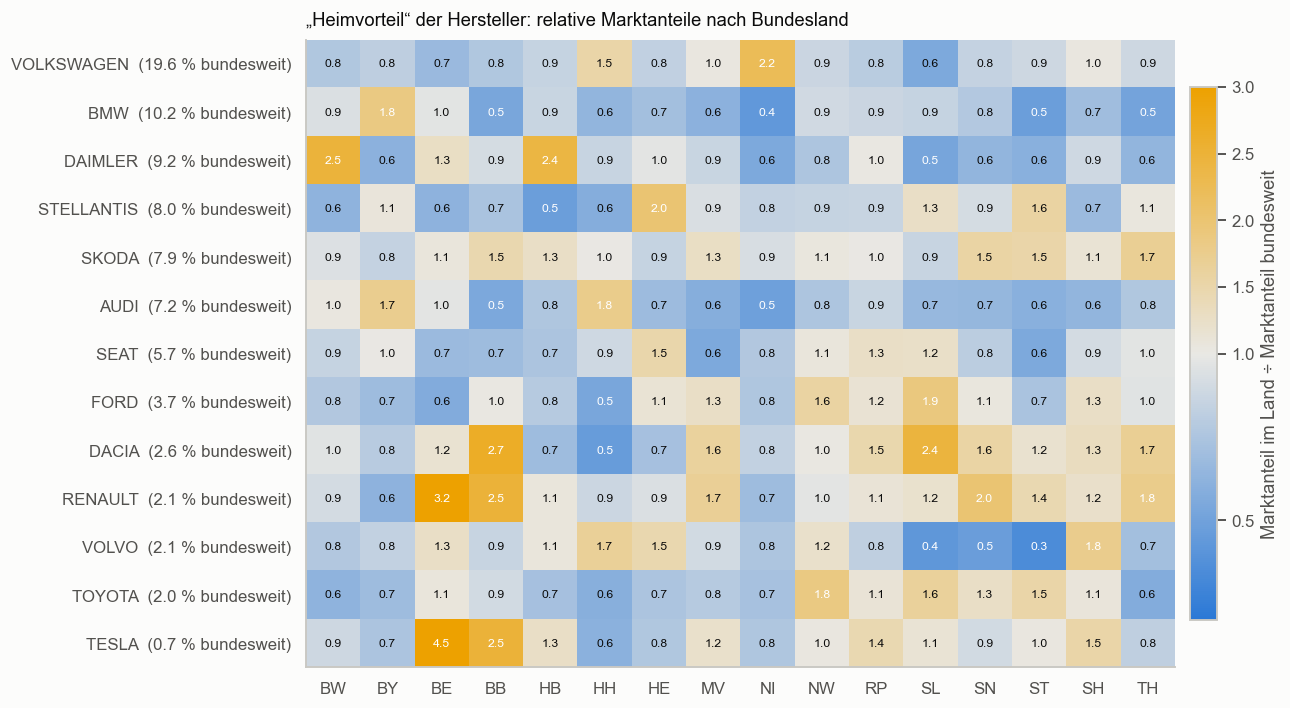

In [9]:
# „Heimvorteil“: Marktanteil des Herstellers im Land, geteilt durch seinen Bundesanteil
auswahl = rang["Hersteller"].head(12).tolist()
if "TESLA (USA)" not in auswahl:
    auswahl.append("TESLA (USA)")

anteil_land = laender[LAENDER].div(laender[LAENDER].sum(), axis=1)
anteil_bund = laender["DE"] / laender["DE"].sum()
faktor = anteil_land.loc[auswahl].div(anteil_bund[auswahl], axis=0)

cmap = mcolors.LinearSegmentedColormap.from_list("heim", [SERIES[0], "#e9e8e4", SERIES[2]])
norm = mcolors.TwoSlopeNorm(vmin=0.2, vcenter=1.0, vmax=3.0)

fig, ax = plt.subplots(figsize=(12.5, 6.6))
im = ax.imshow(faktor, cmap=cmap, norm=norm, aspect="auto")
ax.set_xticks(range(len(LAENDER)), LAENDER)
ax.set_yticks(range(len(auswahl)),
              [f"{h.split(' (')[0]}  ({anteil_bund[h]*100:.1f} % bundesweit)" for h in auswahl])
for i in range(faktor.shape[0]):
    for j in range(faktor.shape[1]):
        v = faktor.iloc[i, j]
        farbe = INK if 0.55 <= v <= 1.75 else "white"
        ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=8, color=farbe)
cb = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.015)
cb.set_label("Marktanteil im Land ÷ Marktanteil bundesweit")
ax.set_title("„Heimvorteil“ der Hersteller: relative Marktanteile nach Bundesland")
ax.grid(False)
plt.tight_layout()
plt.show()

### Was die Zahlen sagen

Die Heatmap ist eine **Landkarte der Werksstandorte**:

- **VW erreicht in Niedersachsen den Faktor 2,2** – 43,6 % aller dort zugelassenen Neuwagen sind
  Volkswagen (bundesweit 19,6 %). Wolfsburg lässt grüßen: Werksangehörigen-Leasing,
  Eigenzulassungen und regionale Markentreue wirken zusammen.
- **Daimler (2,5×) und Porsche in Baden-Württemberg, BMW (1,9×) und Audi (1,7×) in Bayern,
  Ford (1,6×) in NRW** – dasselbe Muster an jedem Konzernsitz.
- **Tesla** zeigt den stärksten relativen Ausreißer: **Faktor 4,5 in Berlin** und 2,5 in
  Brandenburg (Werk Grünheide) – bei bundesweit nur 0,7 % Marktanteil bleibt das absolut freilich
  klein.
- Importmarken ohne deutsches Werk (Toyota, Škoda, Seat) verteilen sich dagegen bemerkenswert
  gleichmäßig (Faktoren meist 0,7–1,3) – Toyota ist in Bayern mit 0,7 sogar deutlich
  *unter*repräsentiert, wo BMW und Audi den Markt aufsaugen.

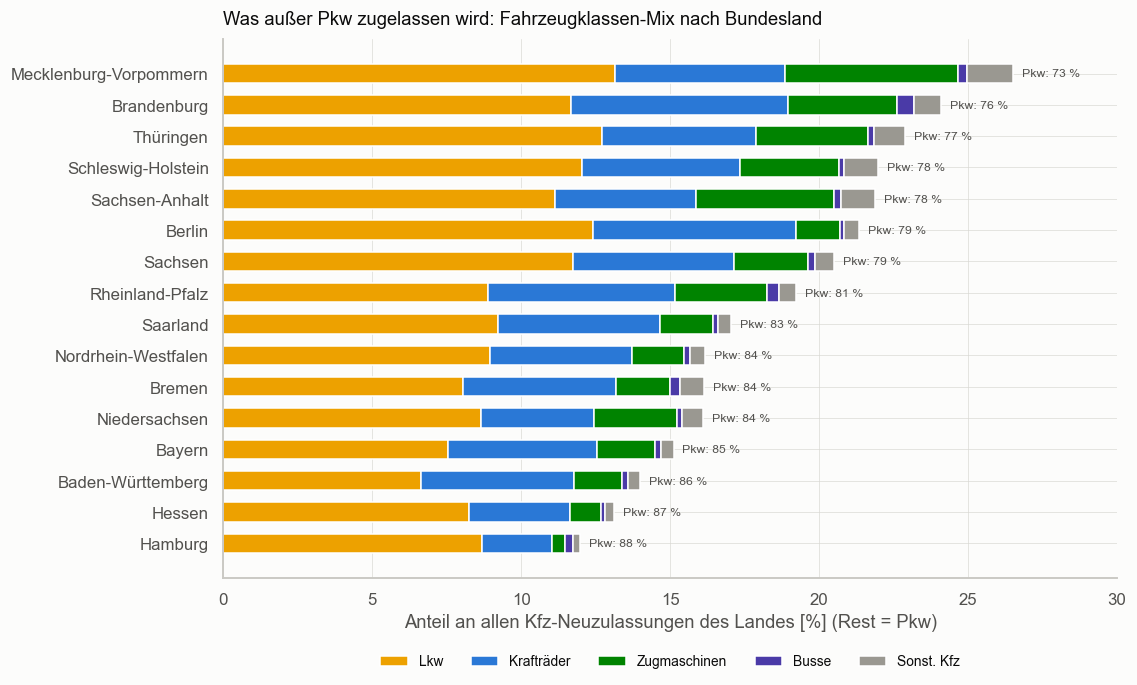

     Pkw  Krafträder  Busse   Lkw  Zugmaschinen  Sonst. Kfz
MV  73.5         5.7    0.3  13.1           5.8         1.6
BB  75.9         7.3    0.6  11.7           3.7         0.9
TH  77.1         5.2    0.2  12.7           3.8         1.0
SH  78.0         5.3    0.2  12.1           3.3         1.1
ST  78.1         4.7    0.2  11.1           4.7         1.1
BE  78.7         6.8    0.1  12.4           1.5         0.5
SN  79.5         5.4    0.2  11.7           2.5         0.7
RP  80.8         6.3    0.4   8.9           3.1         0.6
SL  83.0         5.4    0.2   9.2           1.8         0.4
NW  83.8         4.8    0.2   9.0           1.8         0.5
HB  83.9         5.2    0.3   8.0           1.8         0.8
NI  83.9         3.8    0.2   8.6           2.8         0.7
BY  84.9         5.0    0.2   7.6           1.9         0.4
BW  86.0         5.1    0.2   6.6           1.6         0.4
HE  86.9         3.4    0.1   8.3           1.0         0.3
HH  88.0         2.4    0.3   8.7       

In [10]:
# Fahrzeugklassen-Mix je Bundesland (alle Kfz, nicht nur Pkw)
mix_kl = klassen.drop(index=["Sonstige", "DE"])
ant_kl = mix_kl.div(mix_kl.sum(axis=1), axis=0) * 100
ohne_pkw = ant_kl.drop(columns="Pkw")
ordnung = ohne_pkw.sum(axis=1).sort_values().index          # oben: höchster Nicht-Pkw-Anteil

fig, ax = plt.subplots(figsize=(10.5, 6.4))
links = np.zeros(len(ordnung))
for klasse in ["Lkw", "Krafträder", "Zugmaschinen", "Busse", "Sonst. Kfz"]:
    werte = ohne_pkw.loc[ordnung, klasse].to_numpy()
    ax.barh([LAND_NAME[k] for k in ordnung], werte, left=links,
            color=COL_KLASSE[klasse], height=0.62, label=klasse)
    links += werte
for y, k in enumerate(ordnung):
    ax.text(links[y] + 0.3, y, f"Pkw: {ant_kl.loc[k, 'Pkw']:.0f} %",
            va="center", fontsize=8, color=INK2)
ax.set_xlim(0, 30)
ax.set_xlabel("Anteil an allen Kfz-Neuzulassungen des Landes [%] (Rest = Pkw)")
ax.set_title("Was außer Pkw zugelassen wird: Fahrzeugklassen-Mix nach Bundesland")
ax.legend(ncols=5, loc="upper center", bbox_to_anchor=(0.5, -0.12), fontsize=9)
plt.tight_layout()
plt.show()

print(ant_kl.round(1).sort_values("Pkw").to_string())

### Was die Zahlen sagen

Der Klassen-Mix erzählt Wirtschaftsgeografie: In **Mecklenburg-Vorpommern sind nur 73,5 % der
neuen Kfz Pkw** – dafür **5,8 % Zugmaschinen** (Landwirtschaft!) und 13,1 % Lkw. Auch
Sachsen-Anhalt, Brandenburg und Thüringen zeigen das Agrar-/Logistik-Profil. Das Gegenextrem ist
**Hamburg: 88 % Pkw, 0,4 % Zugmaschinen** – und mit 2,4 % auch der niedrigste Kraftradanteil,
während Brandenburg (7,3 %) und Berlin (6,8 %) vorn liegen. Berlins hoher **Lkw-Anteil (12,4 %)**
dürfte wieder ein Haltersitz-Effekt sein (Logistik- und Sharing-Flotten), keine Aussage über den
Verkehr in der Stadt.

## 7. Warum deskriptiv und nicht inferenzstatistisch?

In Übung 5 fehlten uns für Hypothesentests die Voraussetzungen (zu kurze, gestörte Messung).
Hier ist die Lage genau umgekehrt – und das Ergebnis dasselbe:

- Die KBA-Zulassungsstatistik ist eine **Vollerhebung**: Jede einzelne Zulassung des Jahres 2025
  ist erfasst. Ein Signifikanztest beantwortet die Frage „könnte dieser Unterschied durch die
  Zufälligkeit der *Stichprobenziehung* entstanden sein?“ – die sich hier nicht stellt. Die
  beobachteten Unterschiede **sind** (bis auf Erfassungsfehler) die Wahrheit über 2025.
- Selbst wer die Zulassungen als Realisierung eines Zufallsprozesses auffasst
  (Superpopulations-Sicht), gewinnt bei **n = 2.857.591** nichts: Praktisch jeder noch so winzige
  Unterschied würde „hochsignifikant“ – der p-Wert hätte keine Trennschärfe mehr und würde nur
  Relevanz vortäuschen.
- Die ehrliche Währung sind hier **Effektstärken**: Anteile (E-Auto-Quote 18,8 %),
  Verhältnisse (VW in Niedersachsen 2,2-fach überrepräsentiert), Spannweiten (Hessen vs. Berlin
  Faktor 3). Genau die haben wir berichtet.

Inferenz würde erst wieder sinnvoll, wenn man **prognostiziert** (Wie entwickelt sich die
E-Quote 2026?) oder **Teilmengen vergleicht, die als Stichproben entstehen** – beides geben die
vorliegenden Jahressummen nicht her.

## 8. Fazit

**Leitfrage 1 – Marktstruktur:** Der Pkw-Neuwagenmarkt 2025 (2.857.591 Zulassungen) sieht auf
Herstellerebene unkonzentriert aus (HHI 835), ist es auf Konzernebene aber nicht: Der VW-Konzern
vereint 41,5 %, die Top 10 76 %. Die 13 chinesischen Hersteller kommen zusammen erst auf 2,4 %,
Tesla auf 0,7 %.

**Leitfrage 2 – Antriebe:** Hybride führen mit 39 % (Sammelkategorie inkl. Mildhybrid) vor
Benzinern (27 %) und Elektro (19 %); der Diesel (13 %) ist zum hochmotorisierten Flottenantrieb
geschrumpft (nur 22 % privat). Elektroautos liegen beim Privatanteil (36 %) inzwischen leicht
über dem Marktdurchschnitt. Kurios: Gas lebt fast nur noch als Dacia-LPG (75 % privat), und der
Wasserstoff-Pkw-Markt besteht aus 37 Toyota Mirai.

**Leitfrage 3 – Regionen:** Die Zulassungsstatistik bildet Haltersitze ab, nicht Nutzung: Hessen
verzeichnet je 1.000 Einwohner:innen dreimal so viele Pkw-Zulassungen wie Berlin
(Vermieter-/Leasingflotten), und jeder Konzernsitz erzeugt einen messbaren „Heimvorteil“ (VW in
Niedersachsen 2,2×, Daimler in BW 2,5×, Tesla in Berlin 4,5×). Der Fahrzeugklassen-Mix spiegelt
die Wirtschaftsstruktur: Zugmaschinen in MV/ST/BB, fast reine Pkw-Märkte in Hamburg und Hessen.

**Datenqualität:** Inhaltlich makellos – alle Kontrollsummen gehen blattübergreifend exakt auf.
Die Tücken liegen im **Format**: Präsentations-Excel mit verbundenen Zellen (ohne `ffill` verliert
man still die Hälfte der Daten), KBA-Symbolik (`-`, `.`, `/`), Summenzeilen im Datenbereich und
semantischen Fallen (kW = Dauerleistung bei E-Autos, Hersteller ≠ Konzern). Für eine
Open-Data-Plattform wie die Mobilithek wäre ein zusätzliches maschinenlesbares Format (CSV mit
Codeliste) der eigentliche Fortschritt – die Analyse selbst war dann Kleinarbeit, keine Magie.